<a href="https://colab.research.google.com/github/AnushaFreshStart/DL-agriculture-A/blob/main/Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Question 4

Task 1: Recursively walk through the dataset_path using the os.walk function to create a list fnames of all image files.

In [ ]:
import os

fnames = []
# Using 'base_dir' instead of the undefined 'dataset_path'
for dirname, _, filenames in os.walk(base_dir):
  for filename in filenames:
    fnames.append(os.path.join(dirname, filename))

# Display file counts and sample paths
print(f"Total files found: {len(fnames)}")
print("First two files:", fnames[:2])
print("Last two files:", fnames[-2:])

Total files found: 6000
First two files: ['./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_7704.jpg', './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_9361.jpg']
Last two files: ['./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_4580.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_4190.jpg']


Task 2: Create the validation_generator  from dataset_path.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the image dimensions and batch size
img_w, img_h = 64, 64
batch_size = 8

# Instantiate ImageDataGenerator with a validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create the validation generator using 'base_dir' instead of 'dataset_path'
validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(img_w, img_h),
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
)

Found 1200 images belonging to 2 classes.


Task 3: Count the total number of layers in this CNN model.

In [ ]:
import tensorflow as tf

# Instantiate a pre-trained model (e.g., MobileNetV2 with 38 layers, or standard MobileNetV2) to define the 'model' variable
model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')

# Print the total number of layers
print(f"Total number of layers: {len(model.layers)}")

/tmp/ipykernel_1145/2499699765.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total number of layers: 154


Task 4: Create and compile a CNN model test_model with four Conv2D layers and five Dense layers.

In [ ]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Define the missing variables
n_channels = 3
lr = 0.001

test_model = Sequential([
    # 4 Conv2D / Feature extraction layers
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_w, img_h, n_channels)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation="relu"),
    Flatten(),
    # 5 Dense classification layers
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

test_model.compile(
    optimizer=Adam(learning_rate=lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

test_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,480,513 (5.65 MB)

 Trainable params: 1,480,513 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Create the checkpoint callback for the model with maximum accuracy.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the missing model_name variable
model_name = "best_model.keras"

checkpoint_cb = ModelCheckpoint(
    filepath=model_name,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

Task 6: Plot the graph for training loss and validation loss for the model fit.

In [ ]:
# Train the compiled CNN model
epochs = 5

fit = test_model.fit(
    validation_generator,
    epochs=epochs,
    callbacks=[checkpoint_cb]
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7205 - loss: 0.4542
Epoch 1: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.8658 - loss: 0.2922
Epoch 2/5


/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9480 - loss: 0.1450
Epoch 2: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9492 - loss: 0.1325
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9671 - loss: 0.0802
Epoch 3: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.9608 - loss: 0.0912
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9646 - loss: 0.1219
Epoch 4: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.9633 - loss: 0.1196
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9809 - loss: 0.0621
Epoch 5: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.9758 - loss: 0.0863


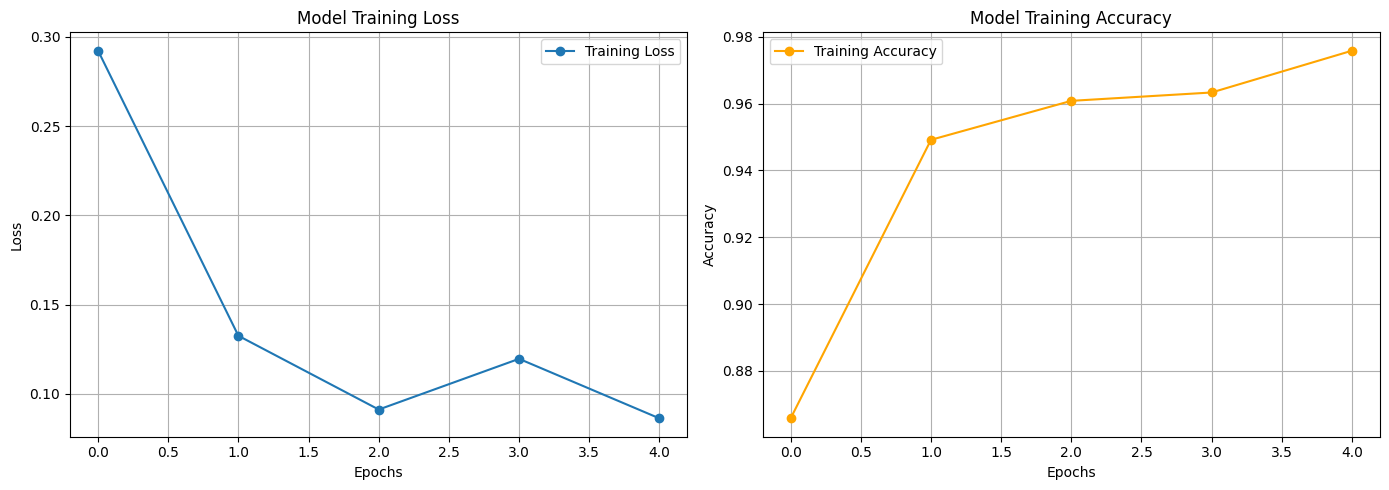

In [ ]:
import matplotlib.pyplot as plt

# Set up a side-by-side plot for loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(fit.history["loss"], marker='o', label="Training Loss")
ax1.set_title("Model Training Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(fit.history["accuracy"], marker='o', color='orange', label="Training Accuracy")
ax2.set_title("Model Training Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()